In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/customer_data_cleaned.csv")
print("Rows loaded:", len(df))
print(df.columns.tolist())

Rows loaded: 500
['customer_id', 'signup_date', 'age', 'gender', 'city', 'segment', 'income', 'purchase_amount', 'satisfaction_score', 'age_was_missing', 'income_was_missing', 'age_band', 'signup_year', 'signup_month', 'income_band']


In [3]:
numeric_cols = ['age', 'income', 'purchase_amount', 'satisfaction_score']

corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))

                      age  income  purchase_amount  satisfaction_score
age                 1.000  -0.009           -0.016               0.075
income             -0.009   1.000            0.031              -0.019
purchase_amount    -0.016   0.031            1.000              -0.042
satisfaction_score  0.075  -0.019           -0.042               1.000


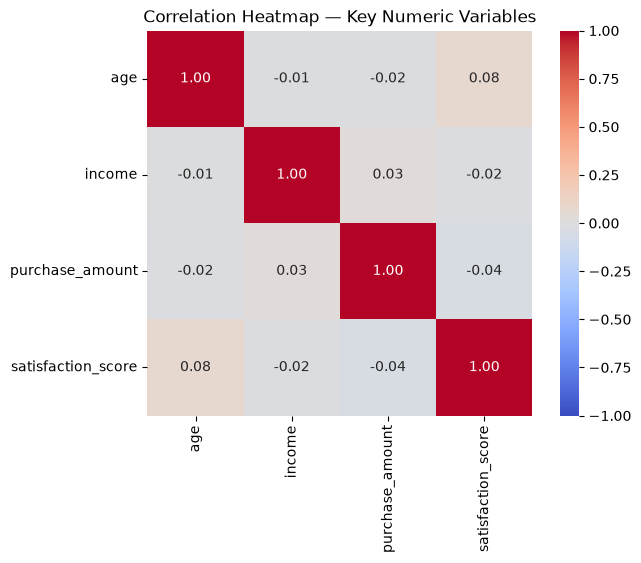

In [4]:
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Correlation Heatmap — Key Numeric Variables')
plt.show()

In [5]:

import numpy as np

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strongest = upper_triangle.unstack().dropna().abs().sort_values(ascending=False)
print("Pairs ranked by absolute correlation strength:")
print(strongest.round(3))

Pairs ranked by absolute correlation strength:
satisfaction_score  age                0.075
                    purchase_amount    0.042
purchase_amount     income             0.031
satisfaction_score  income             0.019
purchase_amount     age                0.016
income              age                0.009
dtype: float64


##  Driver vs Coincidence

- age ↔ satisfaction (0.075): the "strongest" pair, but still near zero. Even if real, the direction (older = slightly more satisfied) is plausible but too weak to act on.
- income ↔ purchase_amount (0.031): confirmed near-zero, consistent with Task 5 finding. Not a driver.
- All other pairs: below 0.05 — safely ignorable as noise.

Conclusion: none of these numeric variables are meaningful linear drivers of each other in this dataset.

##  Multicollinearity Check

Multicollinearity means two predictor variables are so strongly correlated with each other that including both in a model adds no new information and can destabilize estimates.

In this dataset: no multicollinearity concern exists — all pairs are near zero, meaning each variable is essentially independent of the others. All four could safely be included together in a model without any redundancy issue.

## Summary — Relationships Worth Acting On

| Pair | Correlation | Worth acting on? |
|---|---|---|
| age ↔ satisfaction_score | +0.075 | No — too weak |
| income ↔ purchase_amount | +0.031 | No — confirmed non-driver (consistent with Task 5) |
| purchase_amount ↔ satisfaction_score | -0.042 | No — spending more doesn't predict satisfaction |
| All other pairs | < ±0.02 | No |

**Key takeaway:** None of the four core numeric variables show meaningful linear relationships with each other. This is a genuine, important finding — not a failed analysis. It confirms that the real drivers of spending and satisfaction in this dataset are **categorical** (segment, city) rather than numeric (age, income). This is consistent with and reinforces the segment-based findings from Tasks 5, 8, and 10.

**Limitation to note:** Pearson correlation only detects *linear* relationships. A variable could have a strong curved or threshold relationship with another and still show near-zero Pearson correlation. With only 500 records and 4 numeric variables, non-linear patterns couldn't be ruled out without additional scatter plot inspection (which Task 5 already partially covered).